## ChatGPT

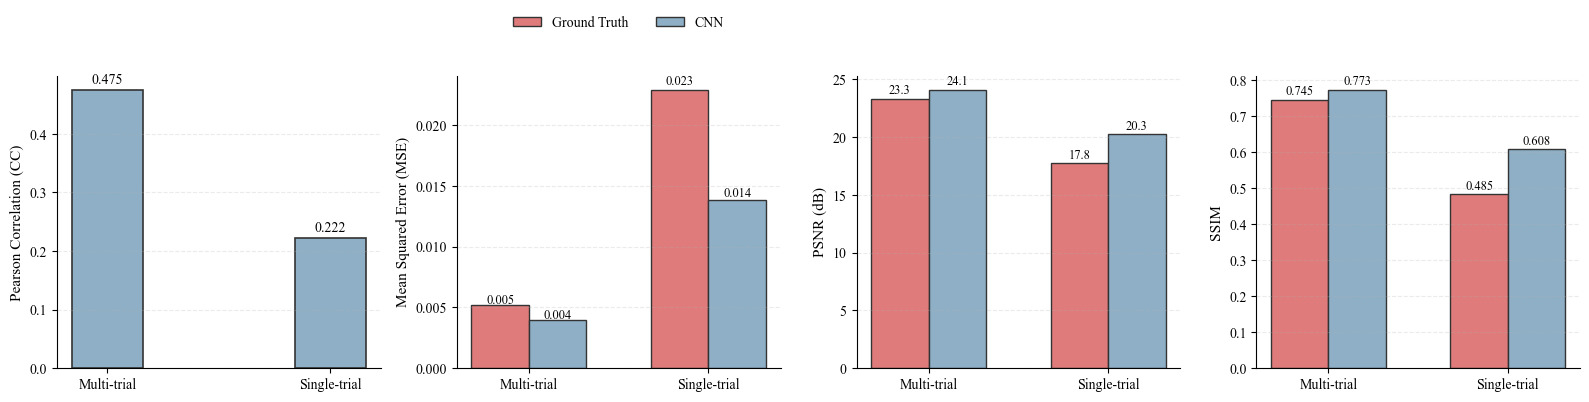

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# 全局风格（论文级）
# =============================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# =============================
# 数据
# =============================
conditions = ['Multi-trial', 'Single-trial']
x = np.arange(len(conditions))
bar_w = 0.32

true_metrics = {
    'MSE': [0.0052, 0.0229],
    'PSNR': [23.2688, 17.7540],
    'SSIM': [0.7449, 0.4851],
}

cnn_metrics = {
    'MSE': [0.0040, 0.0138],
    'PSNR': [24.0742, 20.2518],
    'SSIM': [0.7729, 0.6083],
    'CC': [0.4750, 0.2221],
}

# =============================
# 颜色（优化版）
# =============================
true_color = "#E07B7B"
cnn_color = "#8FAFC6"

# =============================
# 创建图
# =============================
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

metrics = ['CC', 'MSE', 'PSNR', 'SSIM']
ylabels = [
    'Pearson Correlation (CC)',
    'Mean Squared Error (MSE)',
    'PSNR (dB)',
    'SSIM'
]

for i, (metric, ax) in enumerate(zip(metrics, axes)):

    if metric == 'CC':
        vals = cnn_metrics['CC']
        bars = ax.bar(x, vals, width=bar_w, color=cnn_color, edgecolor='#333333', linewidth=1.2)
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.3f}',
                    ha='center', fontsize=10)

    else:
        t = true_metrics[metric]
        c = cnn_metrics[metric]

        b1 = ax.bar(x - bar_w/2, t, width=bar_w,
                    color=true_color, edgecolor='#333333', linewidth=1.0, label='Ground Truth')

        b2 = ax.bar(x + bar_w/2, c, width=bar_w,
                    color=cnn_color, edgecolor='#333333', linewidth=1.0, label='CNN')

        for bars in [b1, b2]:
            for b in bars:
                h = b.get_height()

                if metric == 'PSNR':
                    txt = f'{h:.1f}'
                else:
                    txt = f'{h:.3f}'

                ax.text(b.get_x() + b.get_width()/2, h * 1.02,
                        txt, ha='center', fontsize=9)

    # 统一样式
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=10)
    ax.set_ylabel(ylabels[i], fontsize=11)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(axis='y', linestyle='--', alpha=0.25)

# 统一 legend
axes[1].legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)

plt.tight_layout()
plt.savefig('final_paper_figure.pdf', bbox_inches='tight')
plt.show()

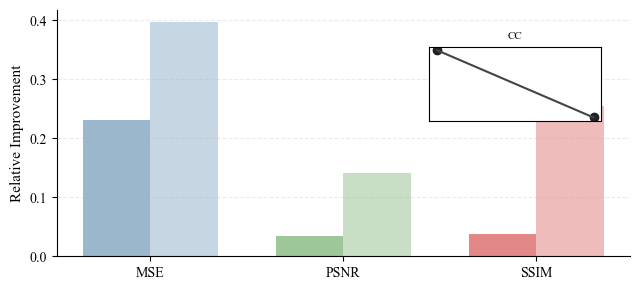

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# 尺寸（论文级）
# =============================
FIG_W, FIG_H = 6.5, 3.0
LABEL_SIZE = 11
TICK_SIZE = 10
ANNOT_SIZE = 9

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# =============================
# 数据
# =============================
metrics = ['MSE', 'PSNR', 'SSIM']

gt = {
    'MSE': np.array([0.0052, 0.0229]),
    'PSNR': np.array([23.2688, 17.7540]),
    'SSIM': np.array([0.7449, 0.4851]),
}

cnn = {
    'MSE': np.array([0.0040, 0.0138]),
    'PSNR': np.array([24.0742, 20.2518]),
    'SSIM': np.array([0.7729, 0.6083]),
    'CC': np.array([0.4750, 0.2221])
}

# =============================
# 归一化 improvement
# =============================
improve = {}

# MSE（反向）
improve['MSE'] = (gt['MSE'] - cnn['MSE']) / gt['MSE']

# 其他
for m in ['PSNR', 'SSIM']:
    improve[m] = (cnn[m] - gt[m]) / np.abs(gt[m])

# multi vs single
multi = [improve[m][0] for m in metrics]
single = [improve[m][1] for m in metrics]

# =============================
# 绘图
# =============================
x = np.arange(len(metrics))
bar_w = 0.35

colors = ['#8FAFC6', '#93C08E', '#E07B7B']

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for i in range(len(metrics)):
    ax.bar(x[i] - bar_w/2, multi[i],
           width=bar_w, color=colors[i], alpha=0.9)

    ax.bar(x[i] + bar_w/2, single[i],
           width=bar_w, color=colors[i], alpha=0.5)

# 标签
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=TICK_SIZE)

ax.set_ylabel('Relative Improvement', fontsize=LABEL_SIZE)

ax.grid(axis='y', linestyle='--', alpha=0.25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =============================
# inset（CC）
# =============================
ax_inset = ax.inset_axes([0.65, 0.55, 0.3, 0.3])

cc = cnn['CC']
ax_inset.plot([0,1], cc, color='#444')
ax_inset.scatter([0,1], cc, color='#222')

ax_inset.set_title('CC', fontsize=8)
ax_inset.set_xticks([])
ax_inset.set_yticks([])

plt.tight_layout()
plt.savefig('final_grouped.pdf', bbox_inches='tight')
plt.show()

## Claude

C:\Users\tjh20\AppData\Local\Temp\ipykernel_39900\773846256.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved!


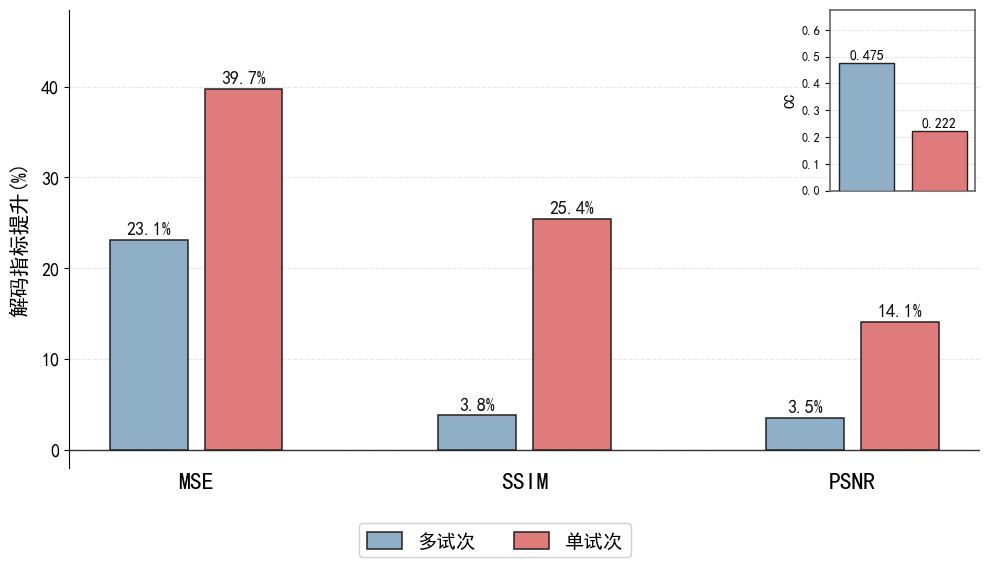

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =============================
# 全局风格（论文级 + 中文支持）
# =============================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# =============================
# 原始数据
# =============================
true_metrics = {
    'MSE':  [0.0052, 0.0229],
    'PSNR': [23.2688, 17.7540],
    'SSIM': [0.7449, 0.4851],
}
cnn_metrics = {
    'MSE':  [0.0040, 0.0138],
    'PSNR': [24.0742, 20.2518],
    'SSIM': [0.7729, 0.6083],
    'CC':   [0.4750, 0.2221],
}

# =============================
# 计算提升率
# MSE: 越小越好 → (GT - CNN) / GT * 100
# PSNR/SSIM: 越大越好 → (CNN - GT) / GT * 100
# =============================
def improvement(gt_vals, cnn_vals, metric):
    gt  = np.array(gt_vals)
    cnn = np.array(cnn_vals)
    if metric == 'MSE':
        return (gt - cnn) / gt * 100
    else:
        return (cnn - gt) / gt * 100

impr = {
    'MSE':  improvement(true_metrics['MSE'],  cnn_metrics['MSE'],  'MSE'),
    'PSNR': improvement(true_metrics['PSNR'], cnn_metrics['PSNR'], 'PSNR'),
    'SSIM': improvement(true_metrics['SSIM'], cnn_metrics['SSIM'], 'SSIM'),
}

# =============================
# 布局参数
# PSNR 排最右（柱子最矮），为嵌入 CC 小图留出垂直空间
# =============================
conditions   = ['多试次', '单试次']
metric_names = ['MSE', 'SSIM', 'PSNR']

group_gap = 1.6
bar_w     = 0.38
cond_gap  = 0.08
offsets   = np.array([-(bar_w + cond_gap)/2,
                       (bar_w + cond_gap)/2])
group_centers = np.arange(len(metric_names)) * group_gap

multi_color  = "#8FAFC6"
single_color = "#E07B7B"
# =============================
# 主图
# =============================
fig, ax = plt.subplots(figsize=(10, 5.5))

for ci, (color, cond) in enumerate(zip([multi_color, single_color], conditions)):
    xs   = group_centers + offsets[ci]
    ys   = [impr[m][ci] for m in metric_names]
    bars = ax.bar(xs, ys, width=bar_w, color=color,
                  edgecolor='#222222', linewidth=1.1,
                  label=cond, zorder=3)
    for b, val in zip(bars, ys):
        ax.text(b.get_x() + b.get_width() / 2,
                val + 0.35,
                f'{val:.1f}%',
                ha='center', va='bottom',
                fontsize=13, fontweight='bold',
                color='#111111')

# 零基准线（唯一的 x 方向参考线）
ax.axhline(0, color='#333333', linewidth=1.0, zorder=2)

# x 轴：只留刻度标签，隐藏 spine，避免与 axhline 重叠出现两条线
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', length=0)   # 去掉刻度短线

ax.set_xticks(group_centers)
ax.set_xticklabels(['MSE', 'SSIM', 'PSNR'], fontsize=17, fontweight='bold')
ax.set_ylabel('解码指标提升(%)', fontsize=15, labelpad=8)
ax.tick_params(axis='y', labelsize=13)

ymax = max(v for vals in impr.values() for v in vals)
ax.set_ylim(-2, ymax * 1.22)
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

handles, labels = ax.get_legend_handles_labels()

# =============================
# 嵌入小图：CC，放在 PSNR 组上方空白处
# 正方形、全包围边框、无 x 轴刻度标注
# =============================
ax_inset = inset_axes(ax,
                      width='16%', height='42%',
                      loc='upper right',
                      bbox_to_anchor=(0.0, 0.06, 0.995, 0.94),
                      bbox_transform=ax.transAxes,
                      borderpad=0)

cc_vals   = cnn_metrics['CC']
xi        = np.array([0.25, 0.75])

for xi_pos, val, color in zip(xi, cc_vals, [multi_color, single_color]):
    ax_inset.bar(xi_pos, val, width=0.38,
                 color=color, edgecolor='#222222',
                 linewidth=1.0, zorder=3)
    ax_inset.text(xi_pos, val + 0.006,
                  f'{val:.3f}',
                  ha='center', va='bottom',
                  fontsize=10, fontweight='bold')

ax_inset.set_xlim(0.0, 1.0)
ax_inset.set_ylim(0, max(cc_vals) * 1.42)
ax_inset.set_ylabel('CC', fontsize=11, labelpad=4)
ax_inset.tick_params(axis='y', labelsize=9)

# 全包围边框，去掉 x 轴标注
ax_inset.set_xticks([])
for spine in ax_inset.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor('#666666')

ax_inset.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# =============================
# 图例：整张图正下方
# ================================
fig.legend(handles, labels,
           loc='lower center',
           ncol=2,
           fontsize=14,
           frameon=True,
           framealpha=0.9,
           edgecolor='#cccccc',
           handlelength=1.8,
           handleheight=1.0,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.savefig('single_vs_multi.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig('single_vs_multi.png',
            bbox_inches='tight', dpi=300)
print("Saved!")